In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import shap
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv("../data/insurance_data_cleaned.csv")

C:\Users\pc\AppData\Local\Temp\ipykernel_13504\4040068463.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/insurance_data_cleaned.csv")


In [9]:
df["VehicleAge"] = 2025 - df["RegistrationYear"]

In [10]:
df["HasClaim"] = np.where(df["TotalClaims"] > 0, 1, 0)

In [11]:
df = df.fillna(0)

In [12]:
categorical_cols = df.select_dtypes(include="object").columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

C:\Users\pc\AppData\Local\Temp\ipykernel_13504\3612009950.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


In [13]:
claim_df = df[df["TotalClaims"] > 0]

X = claim_df.drop(columns=["TotalClaims"])
y = claim_df["TotalClaims"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

In [16]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

In [17]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

In [18]:
def evaluate_model(y_true, preds):
    rmse = np.sqrt(mean_squared_error(y_true, preds))
    r2 = r2_score(y_true, preds)
    return rmse, r2

In [19]:
lr_rmse, lr_r2 = evaluate_model(y_test, lr_preds)
rf_rmse, rf_r2 = evaluate_model(y_test, rf_preds)
xgb_rmse, xgb_r2 = evaluate_model(y_test, xgb_preds)

In [20]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,1.222015e-09,1.000000
1,Random Forest,3.398084e+03,0.992820
2,XGBoost,2.703915e+03,0.995454


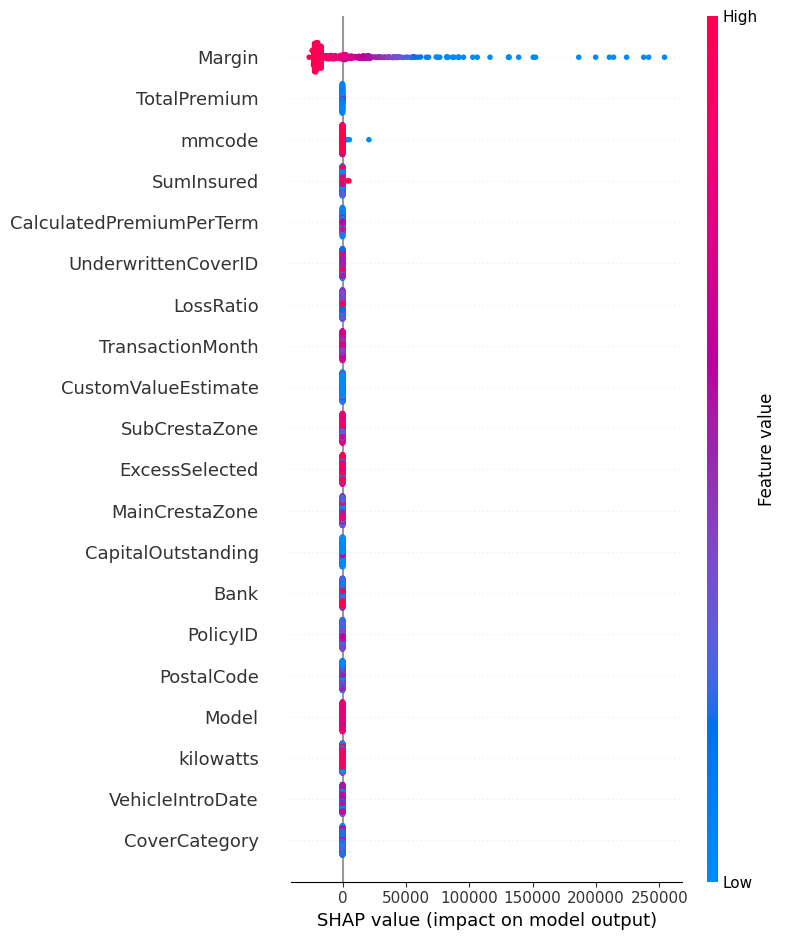

In [21]:
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)